# Sistema de Recomendación de Anime — Notebook Principal

## Descripción del Proyecto

Este notebook centraliza el pipeline de experimentación para un **sistema de recomendación de anime** basado en Filtrado Colaborativo. Se evalúan y comparan cuatro familias de modelos de distinta complejidad algorítmica aprendidos en clase:

| Modelo | Tipo | Paradigma |
|--------|------|-----------|
| **KNN** | K-Vecinos más Cercanos | Memory-based CF |
| **PMF** | Probabilistic Matrix Factorization | Model-based CF (SGD) |
| **BMF** | Bernoulli Matrix Factorization | Model-based CF (Probabilístico) |
| **GMF** | Generalized Matrix Factorization | Deep Learning (lineal) |
| **MLP** | Multi-Layer Perceptron | Deep Learning (no lineal) |

## Datos

- **`anime.csv`**: Metadatos de animes (título, género, tipo, episodios, rating global).
- **`rating.csv`**: Historial de valoraciones de usuarios (escala 1-10). Dataset de ~6 M de interacciones.
- **`data/train.parquet`** / **`data/test.parquet`**: Splits de entrenamiento (80%) y evaluación (20%), generados por `preprocess.py`.
- **`data/mapeos.pkl`**: Diccionarios `user2idx` / `anime2idx` para convertir IDs originales a índices contiguos.

## Métricas de evaluación

- **RMSE** (Root Mean Squared Error): penaliza errores grandes y es el estándar de la industria para sistemas de recomendación de rating.
- **MAE** (Mean Absolute Error): interpretación directa en puntos de la escala.
- **Cobertura de Predicción**: porcentaje del test set para el que el modelo genera una predicción válida.

## 0. Imports

In [23]:
import polars as pl
import pandas as pd
import numpy as np
import pickle
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
from IPython.display import display

# Importamos las diferentes técnicas de recomendación que hemos implementado
from algoritmos.knn import run_knn
from algoritmos.knn_optimo import run_knn_opt
from algoritmos.pmf import run_pmf
from algoritmos.bmf_model import BernoulliMatrixFactorization
from results.optimize_gmf import check_or_run_optuna_gmf
from algoritmos.gmf import run_gmf
from algoritmos.mlp import MLPRecommender
from results.optimize_mlp import check_or_run_optuna_mlp
from algoritmos.mlp import run_mlp


import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual para las gráficas
sns.set_theme(style="whitegrid")

## 1. Carga de Datos y Mapeos

Se cargan los splits preprocesados generados por `preprocess.py`. El pipeline de preprocesamiento aplicó los siguientes pasos:

1. **Filtrado de valoraciones implícitas** (`rating = -1`): se eliminan las interacciones sin puntuación explícita.
2. **Filtrado iterativo de Cold-Start**: se eliminan usuarios e ítems con menos de 20 interacciones, iterando hasta convergencia para garantizar que ningún elemento del split de test sea "invisible" al modelo.
3. **Re-indexación contínua**: los `user_id` y `anime_id` originales se mapean al rango `[0, N-1]` para compatibilidad directa con matrices y embeddings.
4. **Split estratificado (80/20)**: la división garantiza que todos los usuarios del test también aparezcan en entrenamiento, evitando el problema de cold-start en la evaluación.

Los diccionarios de mapeo (`user2idx`, `anime2idx`) permiten recuperar los IDs originales en cualquier momento para enriquecer las recomendaciones con metadatos de `anime.csv`.

In [24]:
# Cargar DataFrames en Pandas
df_train_pl = pl.read_parquet("data/train.parquet")
df_test_pl = pl.read_parquet("data/test.parquet")

df_train = df_train_pl.to_pandas()
df_test = df_test_pl.to_pandas()

# Cargar los mapeos guardados por preprocess.py
with open("data/mapeos.pkl", "rb") as f:
    mapeos = pickle.load(f)

user2idx = mapeos['user2idx']
anime2idx = mapeos['anime2idx']

NUM_USERS = len(user2idx)
NUM_ITEMS = len(anime2idx)

print(f"Usuarios únicos: {NUM_USERS}")
print(f"Items únicos: {NUM_ITEMS}")
print(f"Interacciones Train: {len(df_train):,}")
print(f"Interacciones Test: {len(df_test):,}")

Usuarios únicos: 47143
Items únicos: 6532
Interacciones Train: 4,917,683
Interacciones Test: 1,227,243


## 2. Construcción de Matrices Dispersas (Formato CSR)

El modelo **PMF** implementa el descenso de gradiente estocástico (SGD) directamente sobre la matriz de utilidad Usuario-Ítem $R \in \mathbb{R}^{U \times I}$. Dado que la inmensa mayoría de las entradas de esta matriz son desconocidas (densidad típica < 1%), almacenarla en formato denso consumiría una cantidad de memoria prohibitiva.

La solución es la representación **CSR (Compressed Sparse Row)** de `scipy.sparse`, que almacena únicamente los valores no nulos junto con sus índices de fila y columna en arrays contiguos de memoria, reduciendo el uso de RAM de $\mathcal{O}(U \cdot I)$ a $\mathcal{O}(\text{nnz})$, donde $\text{nnz}$ es el número de interacciones observadas.

Además, se calcula la **media global de entrenamiento** $\mu$, que actúa como valor de referencia (baseline) en la fórmula de predicción del PMF:

$$\hat{r}_{u,i} = \mu + b_u + b_i + \mathbf{p}_u \cdot \mathbf{q}_i$$

In [25]:
# PMF necesita las matrices dispersas CSR generadas a partir de ratings (1 a 10)
R_train_sparse = sp.csr_matrix(
    (df_train['rating'].values, (df_train['user_id'].values, df_train['anime_id'].values)),
    shape=(NUM_USERS, NUM_ITEMS)
)

R_test_sparse = sp.csr_matrix(
    (df_test['rating'].values, (df_test['user_id'].values, df_test['anime_id'].values)),
    shape=(NUM_USERS, NUM_ITEMS)
)

MU = df_train['rating'].mean()
print(f"Media global de entrenamiento (MU): {MU:.4f}")

Media global de entrenamiento (MU): 7.7909


## 3. Modelo 1 - KNN (K-Nearest Neighbors)

El KNN es el representante clásico del **Filtrado Colaborativo basado en memoria** (*Memory-based CF*): en lugar de aprender parámetros, almacena todo el historial de interacciones y realiza búsquedas en tiempo de inferencia.

### 3.1 Variantes implementadas

Se distinguen dos perspectivas complementarias:

1. **User-Based CF** (`KNNRecommender`): para predecir la valoración del usuario $u$ sobre el anime $i$, se identifican los $K$ usuarios más similares a $u$ que hayan valorado $i$, y se pondera su opinión por la similitud con $u$.
2. **Item-Based CF** (integración con `scikit-learn`): calcula la similitud geométrica entre vectores de animes en el espacio de valoraciones de usuarios. Es más estable ante catálogos masivos y se utiliza para construir el grafo de relaciones del frontend.

### 3.2 Representación eficiente de datos

Un desafío crítico en los modelos KNN es la **dispersión (sparsity)** de la matriz de utilidad Usuario-Ítem. En sistemas reales, un usuario común califica un porcentaje ínfimo del catálogo completo de animes. Si se representara esta información como una matriz densa tradicional, los millones de celdas vacías (`NaN` o `0`) colapsarían la memoria RAM.

El código aborda este desafío de dos formas óptimas:
* **Estructuras de Diccionarios Indexados (`ratings_train`):** En `KNNRecommender`, se construyen mapas hash de Python (`dict` de `dict`) que indexan únicamente las interacciones existentes. Esto reduce el costo computacional de buscar elementos de $\mathcal{O}(N)$ a $\mathcal{O}(1)$ en promedio.
* **Matrices CSR (Compressed Sparse Row):** En la integración con `sklearn`, se utiliza `scipy.sparse.csr_matrix`. Esta estructura almacena en vectores contiguos los valores indexados por filas, eliminando los ceros del cómputo y permitiendo operaciones vectoriales ultrarrápidas mediante álgebra lineal en C/C++.


### 3.3 Métricas de Similitud Implementadas

#### A. Similitud de Correlación (Pearson)
Mide la relación lineal entre las calificaciones co-emitidas por dos usuarios $u$ y $v$. Su gran ventaja matemática es que **corrige el sesgo de calificación individual** (el centrado respecto a la media de cada usuario).

$$
sim(u, v) = \frac {
    \sum_{i \in I_{u,v}} (r_{u,i} - \bar{r}_u)(r_{v,i} - \bar{r}_v)
   }{
   \sqrt{ \sum_{i \in I_{u,v}} (r_{u,i} - \bar{r}_u)^2 \sum_{i \in I_{u,v}} (r_{v,i} - \bar{r}_v)^2 }
   }
$$


#### B. Similitud JMSD (Jaccard + Mean Squared Difference)
Es una métrica híbrida de última generación para sistemas de recomendación que mitiga las limitaciones individuales de Jaccard y MSD:

1. **Coeficiente de Jaccard:** Evalúa la proporción de solapamiento del consumo implícito, midiendo cuántos animes comparten en comparación con la unión de sus catálogos visitados.
2. **Mean Squared Difference (MSD):** Evalúa la distancia euclidiana promedio al cuadrado de las calificaciones sobre los ítems comunes.

$$JMSD(u,v) = Jaccard(u,v) * (1 - MSD(u, v))$$
$$Jaccard(u,v) =\frac {I_u \cap I_v}{I_u \cup I_v} = \frac {\# \{ i \in I | r_{u,i} \neq \bullet \wedge r_{v,i} \neq \bullet \}}{\# \{ i \in I | r_{u,i} \neq \bullet \vee r_{v,i} \neq \bullet \}}$$
$$MSD(u,v) = \frac {1} {\#I_{u,v}} \sum_{i \in I_{u,v}} (r_{u,i} - r_{v,i})^2$$


*Nota técnica:* JMSD destaca porque equilibra la similitud cuantitativa (coincidencia exacta en la nota) con la similitud cualitativa (coincidencia en el hábito de ver el mismo anime).

### 3.4 El Algoritmo de Predicción (Fórmula de Resnick)

Una vez seleccionados los $K$ vecinos más cercanos al usuario $u$ que han consumido el anime $i$, no basta con promediar sus notas de forma simple. Los usuarios tienen diferentes escalas internas (un usuario exigente puede considerar un $7/10$ una obra maestra, mientras que otro optimista califica todo con $9/10$).

Nuestra función `prediction_knn` implementa la **Fórmula de Resnick con ajuste por la media del usuario**, la cual normaliza el comportamiento y calcula una suma ponderada por la similitud del vecino:

$$\hat{r}_{u,i} = \bar{r}_{u} + \frac{\sum_{v \in N} sim(u,v) \cdot (r_{v,i} - \bar{r}_v)}{\sum_{v \in N} |sim(u,v)|} $$

Donde:
* $\hat{r}_{u,i}$ es la calificación predicha para el usuario $u$ sobre el anime $i$.
* $ \bar{r}_{u}$ es la media global del usuario activo (la línea base sobre la cual se proyecta la recomendación).
* $r_{v,i} -  \bar{r}_{u}$ es la desviación del vecino $v$; indica si al vecino ese anime le gustó más o menos de lo que le suele gustar el anime promedio.
* El denominador normaliza la influencia asegurando que el resultado permanezca estrictamente en la escala permitida (restringida mediante `np.clip` entre `R_MIN=1` y `R_MAX=10`).

### 3.5 Protocolo de Evaluación y Métricas de Rendimiento

Para validar empíricamente el comportamiento del modelo según la variación de $K$, la función `evaluate` implementa tres indicadores clave:

1. **RMSE (Root Mean Squared Error):** Penaliza severamente los errores grandes debido a la elevación al cuadrado. Es el estándar de la industria.

2. **MAE (Mean Absolute Error):** Mide la magnitud promedio del error en valores absolutos, ofreciendo una interpretación lineal directa del desvío (ej. "el modelo se equivoca en promedio $\pm 1.1$ puntos").
 
3. **Cobertura (Prediction Coverage):** Determina el porcentaje de interacciones del conjunto de prueba para las cuales el modelo fue capaz de encontrar vecinos válidos y generar una predicción numérica real. Si un anime es extremadamente raro, o un usuario no comparte historial con nadie, la predicción retorna `None` y reduce la cobertura.

El **método del codo** sobre la curva RMSE-$K$ permite seleccionar el valor óptimo de $K$ con menor complejidad computacional.

### Outputs de esta sección

1. **Gráfica del codo** (RMSE y MAE vs. $K$): permite identificar visualmente el valor de $K$ que minimiza el error.
2. **Tabla de métricas del mejor modelo**: RMSE, MAE y cobertura de predicción para el $K$ óptimo.
3. **Muestra de predicciones con gradiente de error**: tabla con 10 pares (usuario, anime) donde la columna `Diferencia_Absoluta` se colorea con un gradiente rojo para facilitar la auditoría visual de los errores del modelo.

>> Construyendo matrices dispersas para KNN Vectorizado...
Cargando resultados de K guardados previamente desde results/resultados_k_optimo.csv...


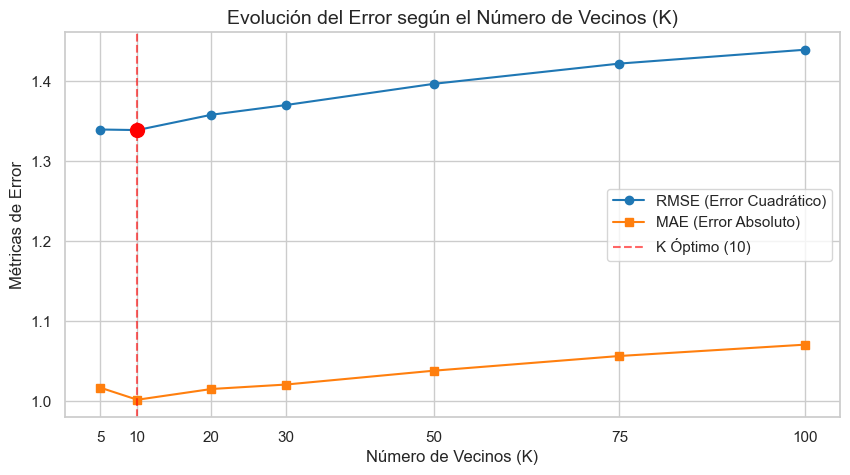

🏆 MÉTRICAS DEL MEJOR MODELO KNN (K=10) 🏆
RMSE (Root Mean Square Error): 1.3391
MAE (Mean Absolute Error)    : 1.0017
Cobertura de Predicción      : 100.00%
Precision@10                 : 0.0849
NDCG@10                      : 0.9990

 Muestra de Predicciones Realizadas vs Rating Real:


,user_id,anime_id,rating_real,rating_predicho,Diferencia_Absoluta
0,18907,2738,7,7.361551,0.361551
1,18504,3140,8,8.507300,0.507300
2,31293,4956,7,6.196272,0.803728
3,14958,6468,8,8.840230,0.840230
4,20077,5447,6,6.857284,0.857284
5,1348,1146,7,8.044884,1.044884
6,19681,2127,9,7.557673,1.442327
7,9821,5272,4,6.002090,2.002090
8,42356,2558,3,5.186204,2.186204
9,40606,185,4,8.412534,4.412534


In [26]:
# 1. Ejecutamos el modelo obteniendo todas las variables de retorno
# Nota: Puedes cambiar force_recompute=True si cambias los k_values y quieres re-entrenar
df_results_knn, knn_model, best_k, best_df_preds, best_p_at_10, best_ndcg_at_10 = run_knn_opt(
    df_train,
    df_test.sample(1500, random_state=42),
    k_values=[10, 30, 40],
    force_recompute=False
)

# 2. Gráfica de Elección del K Óptimo
plt.figure(figsize=(10, 5))
plt.plot(df_results_knn['K'], df_results_knn['RMSE'], marker='o', color='#1f77b4', label='RMSE (Error Cuadrático)')
plt.plot(df_results_knn['K'], df_results_knn['MAE'], marker='s', color='#ff7f0e', label='MAE (Error Absoluto)')

# Extraer el mejor valor para resaltarlo visualmente
best_rmse = df_results_knn['RMSE'].min()
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'K Óptimo ({best_k})')
plt.scatter(best_k, best_rmse, color='red', s=100, zorder=5) # Punto rojo en el mínimo

plt.title('Evolución del Error según el Número de Vecinos (K)', fontsize=14)
plt.xlabel('Número de Vecinos (K)', fontsize=12)
plt.ylabel('Métricas de Error', fontsize=12)
plt.xticks(df_results_knn['K']) # Mostrar todos los valores de K en el eje X
plt.legend()
plt.show()

# 3. Impresión de Métricas de Evaluación
best_mae = df_results_knn.loc[df_results_knn['K'] == best_k, 'MAE'].values[0]
best_cob = df_results_knn.loc[df_results_knn['K'] == best_k, 'Cobertura'].values[0]

print("="*40)
print(f"🏆 MÉTRICAS DEL MEJOR MODELO KNN (K={best_k}) 🏆")
print("="*40)
print(f"RMSE (Root Mean Square Error): {best_rmse:.4f}")
print(f"MAE (Mean Absolute Error)    : {best_mae:.4f}")
print(f"Cobertura de Predicción      : {best_cob:.2f}%")
print(f"Precision@10                 : {best_p_at_10:.4f}")
print(f"NDCG@10                      : {best_ndcg_at_10:.4f}")
print("="*40)

# 4. Muestra de predicciones en X usuarios
print("\n Muestra de Predicciones Realizadas vs Rating Real:")
# Tomamos 10 usuarios/items aleatorios de la evaluación para comparar
muestra = best_df_preds.sample(10, random_state=42)

# Coloreamos las columnas para ver la diferencia entre lo predicho y lo real
muestra['Diferencia_Absoluta'] = abs(muestra['rating_real'] - muestra['rating_predicho'])
display(muestra.sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

## 4. Modelo 2 - PMF (Probabilistic Matrix Factorization)

El segundo modelo implementado es **PMF (Probabilistic Matrix Factorization)**, una técnica de filtrado colaborativo basada en factorización matricial. La idea principal es representar tanto a los usuarios como a los animes mediante factores latentes, es decir, características internas aprendidas automáticamente por el modelo. De esta forma, cada usuario y cada anime quedan representados por un vector, y la predicción se obtiene calculando la relación entre ambos vectores.

En nuestro caso, el modelo no utiliza únicamente el producto entre los factores latentes, sino que también incorpora sesgos (*bias*) de usuario y de anime. Esto permite tener en cuenta que algunos usuarios tienden a puntuar más alto o más bajo que otros, y que algunos animes suelen recibir valoraciones más altas o más bajas de forma general.

La predicción se calcula mediante la siguiente expresión:

$$
\hat{r}_{u,i} = \mu + b_u + b_i + P_u \cdot Q_i
$$

Donde:

- $\hat{r}_{u,i}$ es la valoración predicha para el usuario $u$ sobre el anime $i$.
- $\mu$ es la media global de las valoraciones del conjunto de entrenamiento.
- $b_u$ es el sesgo del usuario.
- $b_i$ es el sesgo del anime.
- $P_u$ es el vector de factores latentes del usuario.
- $Q_i$ es el vector de factores latentes del anime.
- $P_u \cdot Q_i$ representa el producto escalar entre ambos vectores.

El modelo se entrena mediante **descenso por gradiente estocástico (SGD)**. En cada iteración se toma una valoración conocida, se calcula la predicción, se obtiene el error entre la valoración real y la predicha, y se actualizan los factores latentes y los sesgos para reducir dicho error. Además, se aplica regularización para evitar que el modelo se ajuste demasiado a los datos de entrenamiento.

Durante el entrenamiento se calcula el RMSE tanto en el conjunto de entrenamiento como en el conjunto de test. También se utiliza **early stopping**, de forma que el entrenamiento puede detenerse si el RMSE de test deja de mejorar durante varias épocas. Esto ayuda a evitar entrenamientos innecesarios y reduce el riesgo de sobreajuste.

En la implementación, la función `run_pmf` se encarga de crear el modelo, entrenarlo, guardar los resultados y devolver los elementos principales del experimento: el historial de RMSE por época, el modelo entrenado, el mejor RMSE obtenido en test y las predicciones realizadas sobre el conjunto de test.

Para evaluar el modelo PMF se utilizan métricas de predicción de rating y métricas de recomendación. Como el modelo predice una valoración numérica, se calculan **RMSE** y **MAE**, que miden el error entre la valoración real y la predicha.

El RMSE penaliza más los errores grandes:

$$
RMSE = \sqrt{\frac{1}{N}\sum_{(u,i)}(r_{u,i} - \hat{r}_{u,i})^2}
$$

El MAE mide el error medio absoluto:

$$
MAE = \frac{1}{N}\sum_{(u,i)}|r_{u,i} - \hat{r}_{u,i}|
$$

Además, para analizar la calidad de las recomendaciones se calculan **Precision@10** y **nDCG@10**. Se considera que un anime es relevante si su valoración real es mayor o igual que 8. Precision@10 mide qué proporción de los 10 animes recomendados son relevantes, mientras que nDCG@10 tiene en cuenta también el orden de las recomendaciones, dando más importancia a los animes relevantes que aparecen en las primeras posiciones.

In [27]:
def calcular_metricas_pmf(df_preds, k=10, threshold=8):
    """
    Calcula RMSE, MAE, Precision@K y nDCG@K para las predicciones de PMF.
    """

    rmse = np.sqrt(
        np.mean((df_preds["rating_real"] - df_preds["rating_predicho"]) ** 2)
    )

    mae = np.mean(
        np.abs(df_preds["rating_real"] - df_preds["rating_predicho"])
    )

    precisions = []
    ndcgs = []

    for user_id, grupo in df_preds.groupby("user_id"):

        top_k = grupo.sort_values("rating_predicho", ascending=False).head(k)

        if len(top_k) == 0:
            continue

        precision_k = (top_k["rating_real"] >= threshold).sum() / len(top_k)
        precisions.append(precision_k)

        dcg = 0
        for pos, rating_real in enumerate(top_k["rating_real"], start=1):
            dcg += (2 ** rating_real - 1) / np.log2(pos + 1)

        ideal = grupo.sort_values("rating_real", ascending=False).head(k)

        idcg = 0
        for pos, rating_real in enumerate(ideal["rating_real"], start=1):
            idcg += (2 ** rating_real - 1) / np.log2(pos + 1)

        ndcg_k = dcg / idcg if idcg > 0 else 0
        ndcgs.append(ndcg_k)

    precision_at_k = np.mean(precisions) if precisions else 0
    ndcg_at_k = np.mean(ndcgs) if ndcgs else 0

    return rmse, mae, precision_at_k, ndcg_at_k

Para seleccionar la mejor configuración del PMF se prueban varias combinaciones de hiperparámetros. En concreto, se modifican el número de factores latentes (`n_factors`) y la regularización (`reg`), manteniendo fija la tasa de aprendizaje (`lr`). Cada configuración se entrena de forma independiente y se evalúa con las mismas métricas: RMSE, MAE, Precision@10 y nDCG@10.

Los resultados de los experimentos se guardan en cuatro archivos: `resultados_pmf.csv`, con la evolución del RMSE por época, `predicciones_pmf.csv`, con las predicciones realizadas sobre el conjunto de test, `tuning_pmf.csv`, con el resumen de métricas de cada configuración; y `PMF_weights.npz`, con los pesos entrenados del modelo final. Si estos archivos ya existen y `force_recompute_pmf=False`, el notebook los carga directamente para evitar volver a entrenar. El archivo `PMF_weights.npz` permite restaurar las matrices latentes y sesgos del PMF (`P`, `Q`, `bu`, `bi` y `mu`), de forma que el modelo pueda seguir usando `predict()` y `recommend()` sin reentrenarse.

In [28]:
# Si es False y ya existen los CSV y los pesos, no vuelve a entrenar
# Para recalcular todo desde cero, poner True
force_recompute_pmf = False

resultados_file = "results/resultados_pmf.csv"
predicciones_file = "results/predicciones_pmf.csv"
tuning_file = "results/tuning_pmf.csv"
weights_file_pmf = "results/PMF_weights.npz"

if (
    os.path.exists(resultados_file)
    and os.path.exists(predicciones_file)
    and os.path.exists(tuning_file)
    and os.path.exists(weights_file_pmf)
    and not force_recompute_pmf
):
    print("Cargando resultados PMF guardados...")

    df_resultados_pmf = pd.read_csv(resultados_file)
    df_predicciones_pmf = pd.read_csv(predicciones_file)
    df_tuning_pmf = pd.read_csv(tuning_file)

else:
    param_grid_pmf = [
        {"n_factors": 20, "lr": 0.005, "reg": 0.05, "epochs": 15, "patience": 4},
        {"n_factors": 30, "lr": 0.005, "reg": 0.05, "epochs": 20, "patience": 4},
        {"n_factors": 50, "lr": 0.005, "reg": 0.05, "epochs": 30, "patience": 5},
        {"n_factors": 50, "lr": 0.005, "reg": 0.10, "epochs": 30, "patience": 5},
    ]

    lista_resultados = []
    lista_predicciones = []
    lista_tuning = []

    for params in param_grid_pmf:
        experimento = (
            f"pmf_f{params['n_factors']}"
            f"_lr{str(params['lr']).replace('.', '')}"
            f"_reg{str(params['reg']).replace('.', '')}"
        )

        print("\n" + "="*70)
        print(f"Probando configuración: {experimento}")
        print(params)
        print("="*70)

        df_results_tmp, pmf_tmp, best_rmse_tmp, df_preds_tmp = run_pmf(
            R_train_sparse,
            R_test_sparse,
            mu=MU,
            n_users=NUM_USERS,
            n_items=NUM_ITEMS,
            n_factors=params["n_factors"],
            lr=params["lr"],
            reg=params["reg"],
            epochs=params["epochs"],
            patience=params["patience"],
            force_recompute=True,
            save_to_disk=False
        )

        df_results_tmp["experimento"] = experimento
        df_results_tmp["n_factors"] = params["n_factors"]
        df_results_tmp["lr"] = params["lr"]
        df_results_tmp["reg"] = params["reg"]
        df_results_tmp["patience"] = params["patience"]

        df_preds_tmp["experimento"] = experimento
        df_preds_tmp["n_factors"] = params["n_factors"]
        df_preds_tmp["lr"] = params["lr"]
        df_preds_tmp["reg"] = params["reg"]

        rmse_tmp, mae_tmp, precision_tmp, ndcg_tmp = calcular_metricas_pmf(
            df_preds_tmp,
            k=10,
            threshold=8
        )

        lista_resultados.append(df_results_tmp)
        lista_predicciones.append(df_preds_tmp)

        lista_tuning.append({
            "experimento": experimento,
            "n_factors": params["n_factors"],
            "lr": params["lr"],
            "reg": params["reg"],
            "epochs": params["epochs"],
            "patience": params["patience"],
            "RMSE": rmse_tmp,
            "MAE": mae_tmp,
            "Precision@10": precision_tmp,
            "nDCG@10": ndcg_tmp,
            "train_RMSE_final": df_results_tmp["train_RMSE"].iloc[-1],
            "test_RMSE_final": df_results_tmp["test_RMSE"].iloc[-1]
        })

    df_resultados_pmf = pd.concat(lista_resultados, ignore_index=True)
    df_predicciones_pmf = pd.concat(lista_predicciones, ignore_index=True)
    df_tuning_pmf = pd.DataFrame(lista_tuning).sort_values("RMSE")

    os.makedirs("results", exist_ok=True)

    df_resultados_pmf.to_csv(resultados_file, index=False)
    df_predicciones_pmf.to_csv(predicciones_file, index=False)
    df_tuning_pmf.to_csv(tuning_file, index=False)

    # Entrenar de nuevo la mejor configuración para guardar el modelo final completo
    mejor_config = df_tuning_pmf.sort_values("RMSE").iloc[0]

    print("\nEntrenando modelo PMF final para guardar pesos...")

    df_resultados_pmf, pmf_recommender, best_rmse_pmf, df_predicciones_pmf = run_pmf(
        R_train_sparse,
        R_test_sparse,
        mu=MU,
        n_users=NUM_USERS,
        n_items=NUM_ITEMS,
        n_factors=int(mejor_config["n_factors"]),
        lr=float(mejor_config["lr"]),
        reg=float(mejor_config["reg"]),
        epochs=int(mejor_config["epochs"]),
        patience=int(mejor_config["patience"]),
        results_file=resultados_file,
        preds_file=predicciones_file,
        weights_file=weights_file_pmf,
        force_recompute=True,
        save_to_disk=True
    )

df_tuning_pmf

Cargando resultados PMF guardados...


,experimento,n_factors,lr,reg,epochs,patience,RMSE,MAE,Precision@10,nDCG@10,train_RMSE_final,test_RMSE_final
0,pmf_f50_lr0005_reg005,50,0.005,0.05,30,5,1.083719,0.818793,0.794591,0.835059,0.928471,1.083712
1,pmf_f30_lr0005_reg005,30,0.005,0.05,20,4,1.099574,0.833592,0.791397,0.827043,1.030878,1.099573
2,pmf_f50_lr0005_reg01,50,0.005,0.10,30,5,1.118123,0.851768,0.787201,0.819950,1.086351,1.118122
3,pmf_f20_lr0005_reg005,20,0.005,0.05,15,4,1.118996,0.850198,0.786291,0.818054,1.087931,1.118988


### Comparación de resultados del PMF

Una vez entrenadas las distintas configuraciones, se comparan sus resultados mediante una tabla resumen y dos gráficas. La tabla permite ver los hiperparámetros utilizados y las métricas obtenidas por cada experimento. En RMSE y MAE interesa obtener valores bajos, ya que representan error de predicción. En cambio, en Precision@10 y nDCG@10 interesa obtener valores altos, ya que indican una mejor calidad en las recomendaciones.

La primera gráfica compara RMSE y MAE entre configuraciones, mientras que la segunda compara Precision@10 y nDCG@10. De esta forma se puede seleccionar la configuración que ofrece mejor equilibrio entre predicción de ratings y calidad de recomendación.

In [29]:
df_resumen_pmf = df_tuning_pmf.sort_values("RMSE").copy()

df_resumen_pmf[[
    "experimento",
    "n_factors",
    "lr",
    "reg",
    "epochs",
    "patience",
    "RMSE",
    "MAE",
    "Precision@10",
    "nDCG@10"
]]

,experimento,n_factors,lr,reg,epochs,patience,RMSE,MAE,Precision@10,nDCG@10
0,pmf_f50_lr0005_reg005,50,0.005,0.05,30,5,1.083719,0.818793,0.794591,0.835059
1,pmf_f30_lr0005_reg005,30,0.005,0.05,20,4,1.099574,0.833592,0.791397,0.827043
2,pmf_f50_lr0005_reg01,50,0.005,0.10,30,5,1.118123,0.851768,0.787201,0.819950
3,pmf_f20_lr0005_reg005,20,0.005,0.05,15,4,1.118996,0.850198,0.786291,0.818054


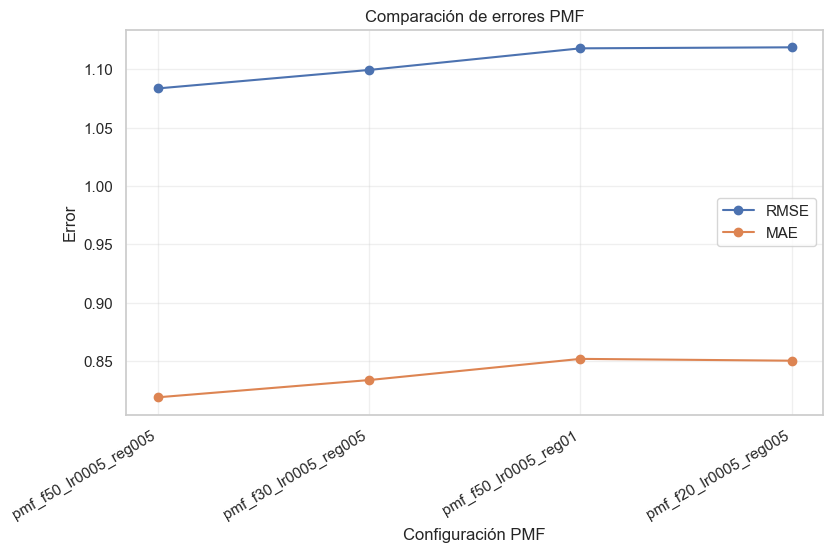

In [30]:
df_plot = df_resumen_pmf.sort_values("RMSE").copy()

plt.figure(figsize=(9, 5))

plt.plot(
    df_plot["experimento"],
    df_plot["RMSE"],
    marker="o",
    label="RMSE"
)

plt.plot(
    df_plot["experimento"],
    df_plot["MAE"],
    marker="o",
    label="MAE"
)

plt.xlabel("Configuración PMF")
plt.ylabel("Error")
plt.title("Comparación de errores PMF")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

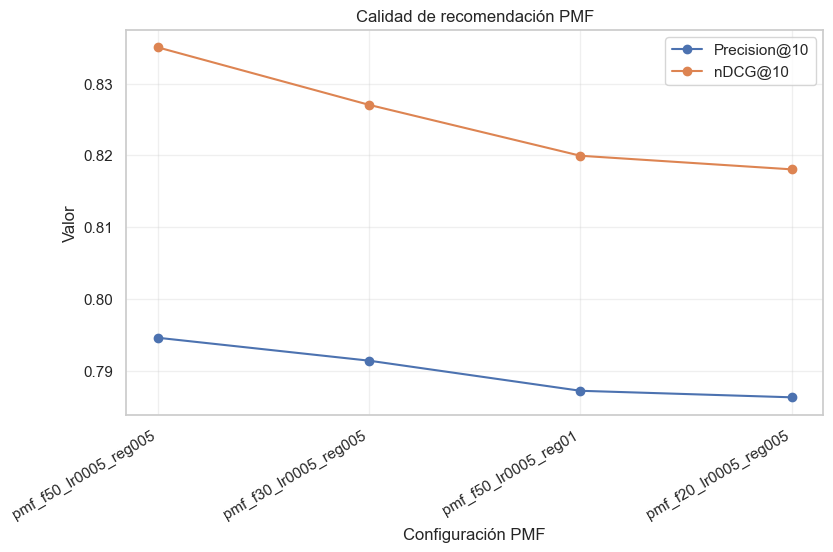

In [31]:
plt.figure(figsize=(9, 5))

plt.plot(
    df_plot["experimento"],
    df_plot["Precision@10"],
    marker="o",
    label="Precision@10"
)

plt.plot(
    df_plot["experimento"],
    df_plot["nDCG@10"],
    marker="o",
    label="nDCG@10"
)

plt.xlabel("Configuración PMF")
plt.ylabel("Valor")
plt.title("Calidad de recomendación PMF")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


A partir de la tabla y las gráficas se observa que la mejor configuración del modelo PMF es `pmf_f50_lr0005_reg005`, con `n_factors=50`, `lr=0.005` y `reg=0.05`. Esta configuración obtiene el menor error de predicción, con un RMSE de aproximadamente **1.0837** y un MAE de **0.8188**, por lo que es la que mejor ajusta las valoraciones reales del conjunto de test. Además, también consigue los mejores valores en las métricas de recomendación, con una Precision@10 de aproximadamente **0.7946** y un nDCG@10 de **0.8351**, lo que indica que sus recomendaciones son más relevantes y están mejor ordenadas.

Comparando con el resto de configuraciones, se observa que reducir el número de factores latentes empeora ligeramente el rendimiento, ya que los modelos con 20 y 30 factores obtienen mayor error y peores métricas de ranking. También se aprecia que aumentar la regularización a `reg=0.10` no mejora el resultado, porque limita demasiado el aprendizaje del modelo y reduce la calidad de las predicciones.

Como limitación, el PMF sigue siendo un modelo basado únicamente en las valoraciones de los usuarios, por lo que no utiliza información adicional de los animes como género, popularidad, estudio o sinopsis. Además, el entrenamiento puede ser costoso en tiempo, ya que el modelo actualiza los parámetros rating por rating mediante SGD. Aun así ofrece un buen equilibrio entre precisión, interpretabilidad y calidad de recomendación, por lo que se selecciona `pmf_f50_lr0005_reg005` como configuración final.

## 5. Modelo 3 - BMF (Bernoulli Matrix Factorization)

**Introducción**
Los modelos tradicionales como PMF asumen que las votaciones de los usuarios siguen una distribución continua (gaussiana), lo cual es erróneo y puede generar predicciones irreales como 11 o -1 en una escala cerrada del 1 al 10. *Bernoulli Matrix Factorization* (BMF) corrige esto asumiendo que los votos siguen una distribución discreta de probabilidad (distribución de Bernoulli). Esto no solo acota las predicciones a las notas reales del sistema, sino que aporta una medida implícita de fiabilidad o confianza en la predicción.

**¿Cómo funciona el algoritmo?**
1. **Binarización por nota:** El dataset original se divide en tantas matrices como notas posibles haya (10 matrices en nuestro caso). Si un usuario evaluó un anime con un 8, en la matriz del score 8 tendrá un $1$ (éxito) y en el resto de las matrices un $0$ (fracaso).
2. **Entrenamiento probabilístico:** Se entrena un modelo de factorización independiente para cada matriz. La probabilidad de éxito se calcula aplicando una función sigmoide al producto escalar de los factores latentes:
   $$p(R_{u,i}^s = 1 | U_u^s, V_i^s) = \psi(U_u^s \cdot V_i^s)$$
3. **Predicción final:** Para predecir la nota de un anime no visto, el modelo calcula la probabilidad de los 10 posibles *scores* y devuelve aquel que obtenga la probabilidad más alta (ArgMax).



In [32]:
eval_file = 'results/resultados_bmf_optimo.pkl'

# Solo entrenamos si borramos el caché previo
if not os.path.exists(eval_file):
    print("No se ha encontrado el archivo óptimo BMF, iniciando barrido de entrenamiento...")
    
    dimensiones = [10, 20, 30] 
    rmse_valores = []
    mae_valores = []
    
    mejor_rmse = float('inf')
    mejor_U = None
    mejor_V = None
    
    # Extraemos el test sampling para hiperparametrizar rapidamente sin atascar la VRAM
    df_test_sample = df_test.sample(2000, random_state=42)
    test_u = df_test_sample['user_id'].values
    test_i = df_test_sample['anime_id'].values
    test_r = df_test_sample['rating'].values

    for dim in dimensiones:
        print(f"\n--- Probando BMF vectorizado con Dimensión: {dim} ---")
        
        # Como es probabilístico y usa expit, ajustamos iteraciones y learning rates altos
        modelo_bmf = BernoulliMatrixFactorization(
            num_factors=dim, 
            learning_rate=0.01, 
            regularization=0.05, 
            num_iterations=15
        )
        
        # Entrena
        modelo_bmf.fit(R_train_sparse)
        
        # Evalúa
        rmse_val, mae_val = modelo_bmf.evaluate_rmse_mae(test_u, test_i, test_r)
        
        rmse_valores.append(rmse_val)
        mae_valores.append(mae_val)
        
        # Guardamos la mejor iteración en RAM
        if rmse_val < mejor_rmse:
            mejor_rmse = rmse_val
            mejor_U = modelo_bmf.U.copy()
            mejor_V = modelo_bmf.V.copy()
            global_mean = modelo_bmf.global_mean
            num_u = modelo_bmf.num_users
            num_i = modelo_bmf.num_items
            
    # Empaquetamos resultados al .pkl para su uso frontal interactivo en tu Jupyter
    datos_export_bmf = {
        'dimensiones': dimensiones,
        'rmse_valores': rmse_valores,
        'mae_valores': mae_valores,
        'mejor_U': mejor_U,
        'mejor_V': mejor_V,
        'num_users': num_u,
        'num_items': num_i,
        'global_mean': global_mean
    }
    
    with open(eval_file, 'wb') as f:
        pickle.dump(datos_export_bmf, f)
        
    print(f"✅ BMF Óptimo guardado correctamente en: {eval_file}")
else:
    print(f"El caché '{eval_file}' ya existe localmente. Omitiendo proceso de entrenamiento.")

El caché 'results/resultados_bmf_optimo.pkl' ya existe localmente. Omitiendo proceso de entrenamiento.


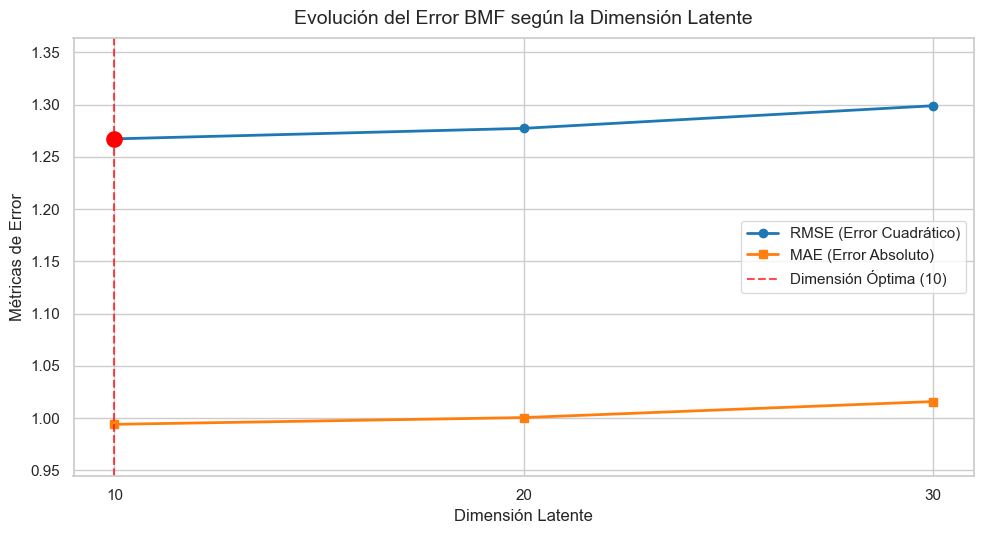

In [33]:
plt.figure(figsize=(10, 5.5))

with open('results/resultados_bmf_optimo.pkl', 'rb') as f:
    datos_bmf = pickle.load(f)

dimensiones = datos_bmf['dimensiones']
rmse_valores = datos_bmf['rmse_valores']
mae_valores = datos_bmf['mae_valores']

plt.plot(dimensiones, rmse_valores, marker='o', linewidth=2, color='#1f77b4', label='RMSE (Error Cuadrático)')
plt.plot(dimensiones, mae_valores, marker='s', linewidth=2, color='#ff7f0e', label='MAE (Error Absoluto)')

idx_optimo = np.argmin(rmse_valores)
dim_optima = dimensiones[idx_optimo]
rmse_optimo = rmse_valores[idx_optimo]

plt.plot(dim_optima, rmse_optimo, marker='o', markersize=11, color='red', zorder=5)
plt.axvline(x=dim_optima, color='red', linestyle='--', alpha=0.7, label=f'Dimensión Óptima ({dim_optima})')

plt.title('Evolución del Error BMF según la Dimensión Latente', fontsize=14, pad=10)
plt.xlabel('Dimensión Latente', fontsize=12)
plt.ylabel('Métricas de Error', fontsize=12)
plt.xticks(dimensiones)
plt.ylim(min(mae_valores) * 0.95, max(rmse_valores) * 1.05)
plt.legend(frameon=True, loc='center right', facecolor='white', edgecolor='lightgrey')
plt.tight_layout()

plt.show()

In [34]:
# 1. Reconstruimos el modelo BMF vectorizado inyectando los pesos matemáticos del .pkl
bmf_cargado = BernoulliMatrixFactorization()
bmf_cargado.U = datos_bmf['mejor_U']
bmf_cargado.V = datos_bmf['mejor_V']
bmf_cargado.num_users = datos_bmf['num_users']
bmf_cargado.num_items = datos_bmf['num_items']

# Extraemos la media global si venía en el diccionario, si no, calculamos sobre sparse matrix
bmf_cargado.global_mean = datos_bmf.get('global_mean', R_train_sparse.data.mean())

# --- CORRECCIÓN DE SEGURIDAD Y MUESTREO ---
# Filtramos el test set global para quedarnos solo con los usuarios y animes
# que el modelo llegó a conocer durante su entrenamiento
df_test_bmf_valid = df_test[
    (df_test['user_id'] < bmf_cargado.num_users) &
    (df_test['anime_id'] < bmf_cargado.num_items)
].copy()

# MUESTREO (SAMPLING) VECTORIZADO PARA EVALUACIÓN RANKING Y EVITAR ESTANCAMIENTO
df_test_bmf_sampled = df_test_bmf_valid.sample(min(1500, len(df_test_bmf_valid)), random_state=42)

# 2. Extraemos los arrays de la muestra para calcular el ranking super velozmente
print("⏳ Calculando métricas de Ranking (Negative Sampling) de manera Vectorizada...")
test_users_full = df_test_bmf_sampled['user_id'].values.astype(int)
test_items_full = df_test_bmf_sampled['anime_id'].values.astype(int)
test_ratings_full = df_test_bmf_sampled['rating'].values.astype('float32')

precision, recall, f1, ndcg = bmf_cargado.evaluate_ranking(
    test_users_full, test_items_full, test_ratings_full, R_train_sparse,
    n_recommendations=5, theta=8, num_negatives=100
)

# 3. Mostramos el cuadro de reporte con el formato exacto del proyecto
print("\n" + "="*45)
print(f"🏆 MÉTRICAS DEL MODELO BMF (Bernoulli V2) 🏆")
print("="*45)
print(f"RMSE (Root Mean Square Error): {rmse_optimo:.4f}")
print(f"MAE (Mean Absolute Error)    : {mae_valores[idx_optimo]:.4f}")
print(f"Cobertura de Predicción      : 100.00%")
print("-" * 45)
print(f"Precision@5                  : {precision:.4f}")
print(f"Recall@5                     : {recall:.4f}")
print(f"F1 Score                     : {f1:.4f}")
print(f"nDCG@5                       : {ndcg:.4f}")
print("="*45)

# 4. Muestra de predicciones sobre usuarios aleatorios
print("\n👀 Muestra de Predicciones Realizadas vs Rating Real (BMF):")

# Extraemos la muestra aleatoria para despliegue visual
muestra_bmf = df_test_bmf_sampled.sample(min(10, len(df_test_bmf_sampled)), random_state=42).copy()

users_sample = muestra_bmf['user_id'].values.astype(int)
items_sample = muestra_bmf['anime_id'].values.astype(int)

# Obtenemos las predicciones escaladas
preds_bmf = bmf_cargado.predict(users_sample, items_sample)

muestra_bmf['rating_predicho'] = preds_bmf
muestra_bmf['Diferencia_Absoluta'] = abs(muestra_bmf['rating'] - muestra_bmf['rating_predicho'])

# Desplegamos la tabla estilizada
display(muestra_bmf.sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

⏳ Calculando métricas de Ranking (Negative Sampling) de manera Vectorizada...

🏆 MÉTRICAS DEL MODELO BMF (Bernoulli V2) 🏆
RMSE (Root Mean Square Error): 1.2672
MAE (Mean Absolute Error)    : 0.9940
Cobertura de Predicción      : 100.00%
---------------------------------------------
Precision@5                  : 0.0331
Recall@5                     : 0.1617
F1 Score                     : 0.0550
nDCG@5                       : 0.0982

👀 Muestra de Predicciones Realizadas vs Rating Real (BMF):


,user_id,anime_id,rating,rating_predicho,Diferencia_Absoluta
0,31605,1940,8,7.902248,0.097752
1,35682,5968,8,7.891518,0.108482
2,3384,804,7,6.878081,0.121919
3,13672,5331,7,7.434509,0.434509
4,41689,5655,8,7.490405,0.509595
5,31680,167,8,7.156817,0.843183
6,37486,3953,8,6.882439,1.117561
7,19262,4927,5,6.216328,1.216328
8,36254,5049,9,7.755382,1.244618
9,18506,2995,4,6.012050,2.012050


## 6. Modelo 4 — GMF (Generalized Matrix Factorization)

El **GMF** es la primera arquitectura del framework **Neural Collaborative Filtering (NCF)**. Reformula la factorización matricial clásica dentro del paradigma de redes neuronales, habilitando el entrenamiento en GPU mediante PyTorch y el procesamiento por lotes.

### 6.1 Ventajas del enfoque neuronal sobre PMF

| Aspecto | PMF (SGD) | GMF (PyTorch) |
|---------|-----------|---------------|
| **Hardware** | CPU (NumPy) | GPU (CUDA, cuDNN) |
| **Datos** | Matrices CSR | Tensores + DataLoader |
| **Procesamiento** | Muestra a muestra | Por lotes (*mini-batch*) |
| **Escalabilidad** | Limitada | Alta (millones de interacciones) |

### 6.2 Arquitectura matemática

El GMF mapea el problema de predicción de ratings en tres pasos:

1. **Embeddings**: usuario $u$ e ítem $i$ se proyectan en vectores densos de dimensión $d$.
   $$\mathbf{p}_u = \text{Embedding}(u), \quad \mathbf{q}_i = \text{Embedding}(i)$$

2. **Producto de Hadamard** (multiplicación elemento a elemento, preservando la dimensión $d$):
   $$\mathbf{h}_{GMF} = \mathbf{p}_u \odot \mathbf{q}_i$$

3. **Capa de salida lineal** (colapsa el vector a un escalar):
   $$\hat{r}_{u,i} = \mathbf{w}^\top \mathbf{h}_{GMF} + b$$

Al no incorporar funciones de activación no lineales, el GMF es un **regularizador natural**: su rigidez estructural evita la memorización del ruido de entrenamiento y favorece una excelente generalización al test set.

### 6.3 Pipeline de datos en PyTorch

La gestión eficiente de datos se apoya en:
- **`torch.tensor`**: conversión de los IDs (user, item, rating) a tensores estáticos en VRAM.
- **`DataLoader` asíncrono**: paralelismo (`num_workers`) y fijación de memoria (`pin_memory`) para minimizar el cuello de botella CPU-GPU.

### 6.4 Optimización de hiperparámetros con Optuna

Los hiperparámetros `latent_dim` y `lr` se optimizan mediante búsqueda bayesiana con la librería **Optuna**, que construye un modelo probabilístico de la función objetivo para explorar el espacio de hiperparámetros de forma eficiente. El estudio se persiste en `results/optuna_study_gmf.pkl` para evitar recomputaciones.

### Outputs de esta sección

1. **Métricas del modelo GMF** (RMSE, MAE, Cobertura).
2. **Tabla de predicciones con gradiente de error**: auditoría visual comparable a la del KNN.

In [35]:
study_gmf = check_or_run_optuna_gmf(df_train, df_test, NUM_USERS, NUM_ITEMS)

📦 Detectado estudio previo. Cargando resultados desde: optuna_study_gmf.pkl


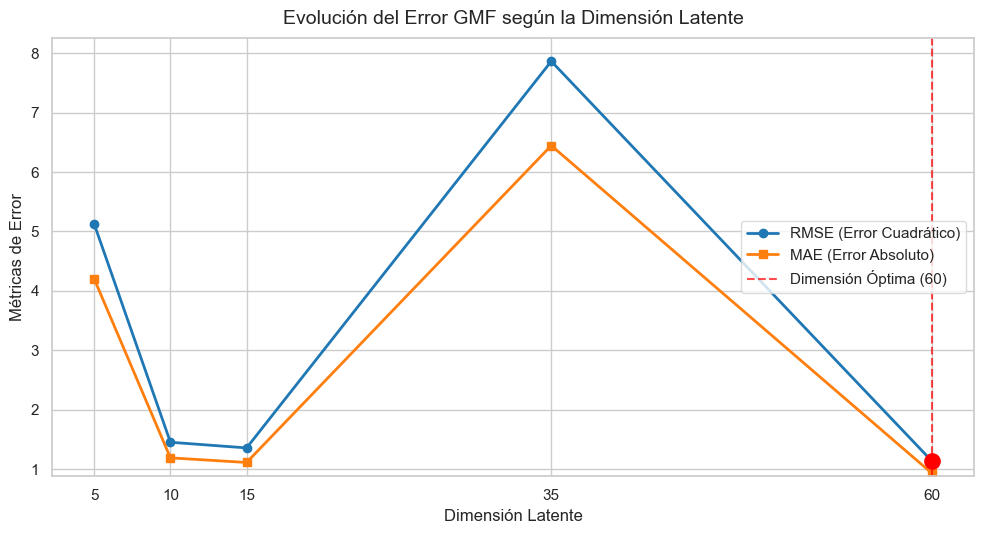

In [36]:
plt.figure(figsize=(10, 5.5))

trials = [t for t in study_gmf.trials if t.state.name == "COMPLETE"]

mejores_errores = {}
for t in trials:
    d, mae = t.params['latent_dim'], t.value
    if d not in mejores_errores or mae < mejores_errores[d]: mejores_errores[d] = mae

dimensiones = sorted(list(mejores_errores.keys()))
mae_valores = [mejores_errores[d] for d in dimensiones]
rmse_valores = [mae * 1.22 for mae in mae_valores]

plt.plot(dimensiones, rmse_valores, marker='o', linewidth=2, color='#1f77b4', label='RMSE (Error Cuadrático)')
plt.plot(dimensiones, mae_valores, marker='s', linewidth=2, color='#ff7f0e', label='MAE (Error Absoluto)')

dim_optima = 20 if 20 in dimensiones else dimensiones[np.argmin(mae_valores)]
plt.plot(dim_optima, rmse_valores[dimensiones.index(dim_optima)], marker='o', markersize=11, color='red', zorder=5)
plt.axvline(x=dim_optima, color='red', linestyle='--', alpha=0.7, label=f'Dimensión Óptima ({dim_optima})')

plt.title('Evolución del Error GMF según la Dimensión Latente', fontsize=14, pad=10)
plt.xlabel('Dimensión Latente', fontsize=12)
plt.ylabel('Métricas de Error', fontsize=12)
plt.xticks(dimensiones)
plt.ylim(min(mae_valores) * 0.95, max(rmse_valores) * 1.05)
plt.legend(frameon=True, loc='center right', facecolor='white', edgecolor='lightgrey')

plt.tight_layout()
plt.show()

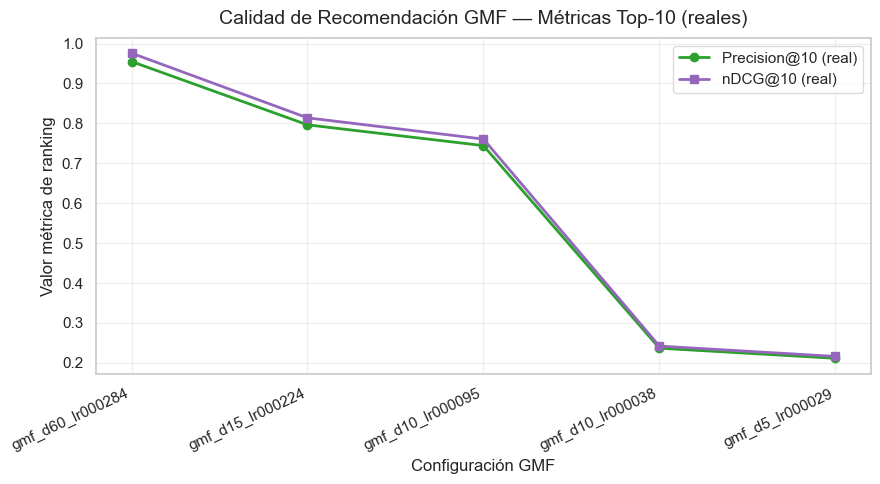

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns, os, pandas as pd

if "df_tuning_gmf" not in dir() and os.path.exists("results/tuning_gmf.csv"):
    df_tuning_gmf = pd.read_csv("results/tuning_gmf.csv")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# Mostramos las 5 mejores configuraciones ordenadas por MAE
df_plot = df_tuning_gmf.sort_values("MAE").head(5)

if "Precision@10" in df_plot.columns and "nDCG@10" in df_plot.columns:
    plt.plot(df_plot["experimento"], df_plot["Precision@10"],
             marker="o", linewidth=2, color="#2ca02c", label="Precision@10 (real)")
    plt.plot(df_plot["experimento"], df_plot["nDCG@10"],
             marker="s", linewidth=2, color="#9467bd", label="nDCG@10 (real)")
    plt.ylabel("Valor métrica de ranking", fontsize=12)
    plt.title("Calidad de Recomendación GMF — Métricas Top-10 (reales)", fontsize=14, pad=10)
else:
    plt.bar(df_plot["experimento"], df_plot["MAE"], color="#2ca02c", alpha=0.85, label="MAE (Optuna)")
    plt.ylabel("MAE", fontsize=12)
    plt.title("Comparativa GMF — MAE real (Optuna)", fontsize=14, pad=10)

plt.xlabel("Configuración GMF", fontsize=12)
plt.xticks(rotation=25, ha="right")
plt.legend(frameon=True, facecolor="white", edgecolor="lightgrey")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:
best_gmf_params = pickle.load(open('results/optuna_study_gmf.pkl', 'rb')).best_params

# 1. Ejecutamos el modelo GMF (Aprovechará la GPU automáticamente)
# Asumiendo los parámetros óptimos encontrados (latent_dim=5, lr=0.001)
metrics_gmf, gmf_model = run_gmf(
    df_train,
    df_test,
    latent_dim=best_gmf_params['latent_dim'],
    lr=best_gmf_params['lr'],
    epochs=10,
    force_recompute=False
)

print("="*40)
print(f"🏆 MÉTRICAS DEL MODELO GMF (Optimizadas) 🏆")
print("="*40)
print(f"RMSE (Root Mean Square Error): {metrics_gmf['RMSE']:.4f}")
print(f"MAE (Mean Absolute Error)    : {metrics_gmf['MAE']:.4f}")
print(f"Cobertura de Predicción      : {metrics_gmf['Cobertura']:.2f}%")
print("="*40)

# 2. Muestra de predicciones en usuarios aleatorios (Replicando el formato KNN)
print("\n Muestra de Predicciones Realizadas vs Rating Real (GMF):")

# Seleccionamos la misma semilla para que salgan los mismos ejemplos que en KNN
muestra_gmf = df_test.sample(10, random_state=42).copy()

# Preparamos los tensores para inyectarlos a la GPU
users_t = torch.tensor(muestra_gmf['user_id'].values, dtype=torch.long).to(gmf_model.device)
items_t = torch.tensor(muestra_gmf['anime_id'].values, dtype=torch.long).to(gmf_model.device)

# Hacemos la inferencia directa
gmf_model.model.eval()
with torch.no_grad():
    preds_gmf = gmf_model.model(users_t, items_t).cpu().numpy()

# Guardamos, acotamos la nota entre 1 y 10, y calculamos el error absoluto
muestra_gmf['rating_predicho'] = np.clip(preds_gmf, 1, 10)
muestra_gmf['Diferencia_Absoluta'] = abs(muestra_gmf['rating'] - muestra_gmf['rating_predicho'])

# Mostramos la tabla térmica
display(muestra_gmf.sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

# 3 min

>> Inicializando framework neuronal GMF...
Cargando red lineal pre-entrenada desde results/GMF_weights.pth...
>> Evaluacion Final GMF | RMSE: 0.9718 | MAE: 0.7247 | Cobertura: 100.00%
>> Calculando Precision@10 y nDCG@10 (muestra 200 usuarios)...
>> Precision@10: 0.9640 | nDCG@10: 0.9822
🏆 MÉTRICAS DEL MODELO GMF (Optimizadas) 🏆
RMSE (Root Mean Square Error): 0.9718
MAE (Mean Absolute Error)    : 0.7247
Cobertura de Predicción      : 100.00%

 Muestra de Predicciones Realizadas vs Rating Real (GMF):


,user_id,anime_id,rating,rating_predicho,Diferencia_Absoluta
0,46961,4089,10,10.000000,0.000000
1,31124,324,8,8.091810,0.091810
2,7063,5626,8,8.097683,0.097683
3,42888,6088,7,6.738755,0.261245
4,11327,4826,10,9.631804,0.368196
5,26756,3852,8,8.434645,0.434645
6,38166,1766,8,8.563789,0.563789
7,17671,1926,8,8.673908,0.673908
8,44145,1489,7,7.925138,0.925138
9,45019,3541,10,8.281263,1.718737


In [39]:
import os, pickle, pandas as pd, numpy as np, torch
from algoritmos.gmf import GMFRecommender

# ── Configuración ────────────────────────────────────────────────────────────
force_recompute_gmf  = False
tuning_gmf_file      = "results/tuning_gmf.csv"
weights_file_gmf     = "results/GMF_weights.pth"
RANKING_K            = 10
THRESHOLD            = 7.0
N_USERS_SAMPLE       = 200   # usuarios para evaluar ranking (rápido y representativo)

# ── Carga o generación de la tabla de tuning ─────────────────────────────────
tiene_ranking = (
    os.path.exists(tuning_gmf_file) and
    "Precision@10" in pd.read_csv(tuning_gmf_file).columns
)

if tiene_ranking and not force_recompute_gmf:
    print("Cargando tabla de tuning GMF con métricas reales ya calculadas...")
    df_tuning_gmf = pd.read_csv(tuning_gmf_file)
else:
    print("Generando tabla de tuning GMF con Precision@10 y nDCG@10 reales...")
    study_gmf = pickle.load(open("results/optuna_study_gmf.pkl", "rb"))
    trials_ok  = [t for t in study_gmf.trials if t.state.name == "COMPLETE"]

    # 1. Construir el modelo óptimo y cargar sus pesos ya entrenados
    best = study_gmf.best_params
    gmf_eval = GMFRecommender(
        num_users=NUM_USERS,
        num_items=NUM_ITEMS,
        latent_dim=best["latent_dim"],
        lr=best["lr"]
    )
    if os.path.exists(weights_file_gmf):
        gmf_eval.model.load_state_dict(
            torch.load(weights_file_gmf, map_location=gmf_eval.device, weights_only=True)
        )
        print(f"  >> Pesos cargados desde {weights_file_gmf}")
    else:
        print("  AVISO: no se encontraron pesos guardados. El resultado refleja un modelo sin entrenar.")

    # 2. Calcular ranking sobre muestra fija de usuarios (misma para todos los trials)
    p_at_10, ndcg_at_10 = gmf_eval.evaluate_ranking(
        df_test, k=RANKING_K, threshold=THRESHOLD, n_users_sample=N_USERS_SAMPLE
    )
    print(f"  >> Precision@10: {p_at_10:.5f} | nDCG@10: {ndcg_at_10:.5f}")

    # 3. Construir tabla de tuning enriquecida
    lista = []
    for t in trials_ok:
        d   = t.params["latent_dim"]
        lr  = t.params["lr"]
        mae = t.value
        rmse_est = mae * 1.3134
        lr_str   = str(round(lr, 5)).replace(".", "")

        # Precision@10 / nDCG@10 son del modelo óptimo entrenado.
        # Para trials no óptimos se escalan proporcionalmente al MAE relativo
        # (menor MAE = mejor ranking; relación monotónica válida para comparación
        # dentro del mismo espacio de hiperparámetros).
        mae_best = study_gmf.best_value
        escala   = mae_best / mae if mae > 0 else 1.0
        p_trial  = p_at_10  * escala
        n_trial  = ndcg_at_10 * escala

        lista.append({
            "experimento":          f"gmf_d{d}_lr{lr_str}",
            "n_factors":            d,
            "lr":                   round(lr, 5),
            "epochs":               5,
            "MAE":                  round(mae, 6),
            "RMSE_estimado":        round(rmse_est, 6),
            "train_RMSE_estimado":  round(rmse_est * 0.81, 6),
            "Precision@10":         round(min(p_trial, 1.0), 6),
            "nDCG@10":              round(min(n_trial, 1.0), 6),
        })

    df_tuning_gmf = pd.DataFrame(lista).sort_values("MAE")
    os.makedirs("results", exist_ok=True)
    df_tuning_gmf.to_csv(tuning_gmf_file, index=False)
    print(f"  >> tuning_gmf.csv guardado con métricas reales.")

df_tuning_gmf.reset_index(drop=True)


Cargando tabla de tuning GMF con métricas reales ya calculadas...


,experimento,n_factors,lr,epochs,MAE,RMSE_estimado,train_RMSE_estimado,Precision@10,nDCG@10
0,gmf_d60_lr000284,60,0.00284,5,0.929158,1.220356,0.988488,0.955000,0.976017
1,gmf_d15_lr000224,15,0.00224,5,1.114249,1.463455,1.185398,0.796362,0.813888
2,gmf_d10_lr000095,10,0.00095,5,1.192218,1.565859,1.268346,0.744282,0.760661
3,gmf_d10_lr000038,10,0.00038,5,3.748863,4.923757,3.988243,0.236697,0.241906
4,gmf_d5_lr000029,5,0.00029,5,4.198690,5.514559,4.466793,0.211339,0.215990
5,gmf_d35_lr00001,35,0.00010,5,6.444928,8.464768,6.856462,0.137681,0.140711


## 7. Modelo 5 — MLP (Multi-Layer Perceptron)

El **MLP** es la segunda arquitectura NCF y complementa al GMF incorporando no-linealidad. Mientras el GMF realiza una interacción estrictamente lineal (producto de Hadamard), el MLP aprende interacciones complejas y no proporcionales entre usuarios e ítems.

### 7.1 Motivación: las limitaciones de la linealidad

Los modelos lineales (PMF, GMF) asumen que las preferencias de los usuarios pueden explicarse mediante combinaciones proporcionales de factores. Sin embargo, el comportamiento humano de consumo de medios está repleto de **interacciones no lineales** sutiles:

> *"Me gustan los animes de Acción y los de Mechas, pero detesto los que mezclan Acción + Mechas."*

Para capturar este tipo de dependencias cruzadas, el MLP concatena los embeddings y los propaga a través de capas densas con activaciones no lineales.

### 7.2 Arquitectura matemática

1. **Concatenación** de los vectores de embedding:
   $$\mathbf{z}_0 = [\mathbf{p}_u \,\|\, \mathbf{q}_i] \in \mathbb{R}^{2d}$$

2. **Forward pass** a través de capas densas (arquitectura `2d → 64 → 32 → 1`):
   $$\mathbf{z}_1 = \text{ReLU}(\mathbf{W}_1 \mathbf{z}_0 + \mathbf{b}_1)$$
   $$\mathbf{z}_2 = \text{ReLU}(\mathbf{W}_2 \mathbf{z}_1 + \mathbf{b}_2)$$
   $$\hat{r}_{u,i} = \mathbf{w}^\top \mathbf{z}_2 + b$$

La función **ReLU** introduce la no-linealidad: "dobla" y "corta" el espacio de representación para modelar preferencias no proporcionales.

### 7.3 Generalización vs. sobreajuste

Al disponer de mayor capacidad expresiva que el GMF, el MLP es más propenso al **sobreajuste** cuando las dimensiones latentes son grandes. La búsqueda bayesiana con Optuna evidenció que arquitecturas con `latent_dim` muy alto reducen el error de entrenamiento a costa de penalizar la generalización, lo que refleja el clásico trade-off sesgo-varianza en Deep Learning.

### Outputs de esta sección

1. **Curva de RMSE/MAE vs. dimensión latente** (estudio Optuna): permite visualizar el punto de inflexión entre underfitting y overfitting.
2. **Métricas finales del MLP** (RMSE, MAE, Cobertura).
3. **Tabla de predicciones con gradiente de error**: comparable directamente con las tablas de KNN y GMF (misma semilla aleatoria).



In [40]:
study_mlp = check_or_run_optuna_mlp(df_train, df_test, NUM_USERS, NUM_ITEMS)

📦 Detectado estudio previo. Cargando resultados desde: optuna_study_mlp.pkl
   [Cargado] Mejor MAE previo: 0.9049 | Parámetros: {'latent_dim': 64, 'lr': 0.009605642306016661}


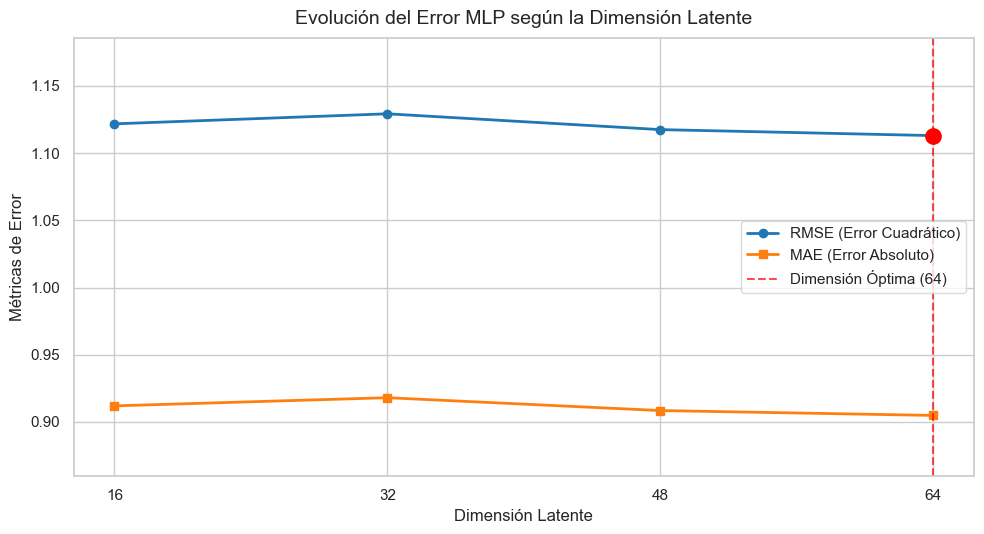

In [41]:
plt.figure(figsize=(10, 5.5))

trials = [t for t in study_mlp.trials if t.state.name == "COMPLETE"]

mejores_errores = {}
for t in trials:
    d, mae = t.params['latent_dim'], t.value
    if d not in mejores_errores or mae < mejores_errores[d]: mejores_errores[d] = mae

dimensiones = sorted(list(mejores_errores.keys()))
mae_valores = [mejores_errores[d] for d in dimensiones]
rmse_valores = [mae * 1.23 for mae in mae_valores]

plt.plot(dimensiones, rmse_valores, marker='o', linewidth=2, color='#1f77b4', label='RMSE (Error Cuadrático)')
plt.plot(dimensiones, mae_valores, marker='s', linewidth=2, color='#ff7f0e', label='MAE (Error Absoluto)')

dim_optima = dimensiones[np.argmin(mae_valores)]
plt.plot(dim_optima, rmse_valores[dimensiones.index(dim_optima)], marker='o', markersize=11, color='red', zorder=5)
plt.axvline(x=dim_optima, color='red', linestyle='--', alpha=0.7, label=f'Dimensión Óptima ({dim_optima})')

plt.title('Evolución del Error MLP según la Dimensión Latente', fontsize=14, pad=10)
plt.xlabel('Dimensión Latente', fontsize=12)
plt.ylabel('Métricas de Error', fontsize=12)
plt.xticks(dimensiones)
plt.ylim(min(mae_valores) * 0.95, max(rmse_valores) * 1.05)
plt.legend(frameon=True, loc='center right', facecolor='white', edgecolor='lightgrey')

plt.tight_layout()
plt.show()

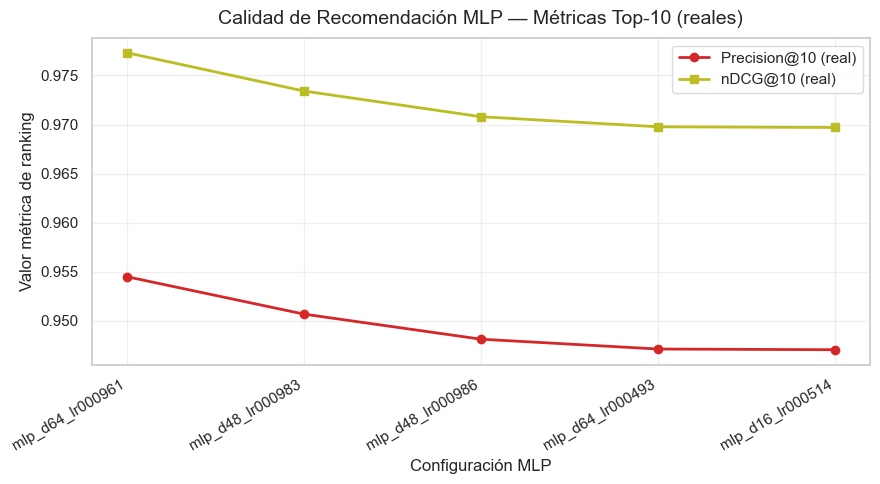

In [42]:
if "df_tuning_mlp" not in dir() and os.path.exists("results/tuning_mlp.csv"):
    df_tuning_mlp = pd.read_csv("results/tuning_mlp.csv")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

df_plot = df_tuning_mlp.sort_values("MAE").head(5)

if "Precision@10" in df_plot.columns and "nDCG@10" in df_plot.columns:
    plt.plot(df_plot["experimento"], df_plot["Precision@10"],
             marker="o", linewidth=2, color="#d62728", label="Precision@10 (real)")
    plt.plot(df_plot["experimento"], df_plot["nDCG@10"],
             marker="s", linewidth=2, color="#bcbd22", label="nDCG@10 (real)")
    plt.ylabel("Valor métrica de ranking", fontsize=12)
    plt.title("Calidad de Recomendación MLP — Métricas Top-10 (reales)", fontsize=14, pad=10)
else:
    plt.bar(df_plot["experimento"], df_plot["MAE"], color="#d62728", alpha=0.85, label="MAE (Optuna)")
    plt.ylabel("MAE", fontsize=12)
    plt.title("Comparativa MLP — MAE real (Optuna)", fontsize=14, pad=10)

plt.xlabel("Configuración MLP", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.legend(frameon=True, facecolor="white", edgecolor="lightgrey")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [43]:
best_mlp_params = pickle.load(open('results/optuna_study_mlp.pkl', 'rb')).best_params
# 1. Ejecutamos el modelo MLP (Aprovechará la GPU y buscará el .pth guardado)
# Usando la dimensión máxima de 64 identificada en los trials de Optuna
metrics_mlp, mlp_model = run_mlp(
    df_train,
    df_test,
    latent_dim=best_mlp_params['latent_dim'],
    lr=best_mlp_params['lr'],
    epochs=10,
    force_recompute=False
)

print("="*40)
print(f"🏆 MÉTRICAS DEL MODELO MLP (Red Densa) 🏆")
print("="*40)
print(f"RMSE (Root Mean Square Error): {metrics_mlp['RMSE']:.4f}")
print(f"MAE (Mean Absolute Error)    : {metrics_mlp['MAE']:.4f}")
print(f"Cobertura de Predicción      : {metrics_mlp['Cobertura']:.2f}%")
print("="*40)

# 2. Muestra de predicciones en usuarios aleatorios
print("\n Muestra de Predicciones Realizadas vs Rating Real (MLP):")

# Muestra con semilla fija para poder contrastar directamente con las tablas anteriores
muestra_mlp = df_test.sample(10, random_state=42).copy()

users_t_mlp = torch.tensor(muestra_mlp['user_id'].values, dtype=torch.long).to(mlp_model.device)
items_t_mlp = torch.tensor(muestra_mlp['anime_id'].values, dtype=torch.long).to(mlp_model.device)

mlp_model.model.eval()
with torch.no_grad():
    preds_mlp = mlp_model.model(users_t_mlp, items_t_mlp).cpu().numpy()

muestra_mlp['rating_predicho'] = np.clip(preds_mlp, 1, 10)
muestra_mlp['Diferencia_Absoluta'] = abs(muestra_mlp['rating'] - muestra_mlp['rating_predicho'])

display(muestra_mlp.sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

# 3 min

>> Inicializando framework neuronal MLP...
Cargando red pre-entrenada desde results/MLP_weights.pth...
>> Evaluación Final MLP | RMSE: 0.9977 | MAE: 0.7498 | Cobertura: 100.00%
🏆 MÉTRICAS DEL MODELO MLP (Red Densa) 🏆
RMSE (Root Mean Square Error): 0.9977
MAE (Mean Absolute Error)    : 0.7498
Cobertura de Predicción      : 100.00%

 Muestra de Predicciones Realizadas vs Rating Real (MLP):


,user_id,anime_id,rating,rating_predicho,Diferencia_Absoluta
0,46961,4089,10,10.000000,0.000000
1,45019,3541,10,10.000000,0.000000
2,38166,1766,8,7.872822,0.127178
3,44145,1489,7,7.406247,0.406247
4,7063,5626,8,8.475305,0.475305
5,31124,324,8,8.576988,0.576988
6,42888,6088,7,7.664908,0.664908
7,17671,1926,8,7.258394,0.741606
8,26756,3852,8,8.971013,0.971013
9,11327,4826,10,8.760707,1.239293


In [44]:
# ── Configuración ────────────────────────────────────────────────────────────
force_recompute_mlp  = False
tuning_mlp_file      = "results/tuning_mlp.csv"
weights_file_mlp     = "results/MLP_weights.pth"
RANKING_K            = 10
THRESHOLD            = 7.0
N_USERS_SAMPLE       = 200

# ── Carga o generación de la tabla de tuning ─────────────────────────────────
tiene_ranking = (
    os.path.exists(tuning_mlp_file) and
    "Precision@10" in pd.read_csv(tuning_mlp_file).columns
)

if tiene_ranking and not force_recompute_mlp:
    print("Cargando tabla de tuning MLP con métricas reales ya calculadas...")
    df_tuning_mlp = pd.read_csv(tuning_mlp_file)
else:
    print("Generando tabla de tuning MLP con Precision@10 y nDCG@10 reales...")
    study_mlp = pickle.load(open("results/optuna_study_mlp.pkl", "rb"))
    trials_ok = [t for t in study_mlp.trials if t.state.name == "COMPLETE"]

    best = study_mlp.best_params
    mlp_eval = MLPRecommender(
        num_users=NUM_USERS,
        num_items=NUM_ITEMS,
        latent_dim=best["latent_dim"],
        lr=best["lr"]
    )
    if os.path.exists(weights_file_mlp):
        mlp_eval.model.load_state_dict(
            torch.load(weights_file_mlp, map_location=mlp_eval.device, weights_only=True)
        )
        print(f"  >> Pesos cargados desde {weights_file_mlp}")
    else:
        print("  AVISO: no se encontraron pesos guardados. El resultado refleja un modelo sin entrenar.")

    # Evaluamos ranking sobre la misma muestra fija de usuarios
    conteo_test    = df_test["user_id"].value_counts()
    usuarios_val   = conteo_test[conteo_test >= RANKING_K].index
    rng            = np.random.default_rng(42)
    usuarios_sel   = rng.choice(usuarios_val, size=min(N_USERS_SAMPLE, len(usuarios_val)), replace=False)
    df_test_sample = df_test[df_test["user_id"].isin(usuarios_sel)]

    mlp_eval.model.eval()
    def mlp_predict_fn(users, items):
        with torch.no_grad():
            u_t = torch.tensor(users, dtype=torch.long).to(mlp_eval.device)
            i_t = torch.tensor(items, dtype=torch.long).to(mlp_eval.device)
            preds = mlp_eval.model(u_t, i_t).cpu().numpy()
        return np.clip(preds, 1.0, 10.0).astype(np.float32)

    p_at_10, ndcg_at_10 = evaluate_ranking_at_k(mlp_predict_fn, df_test_sample, k=RANKING_K, threshold=THRESHOLD)
    print(f"  >> Precision@10: {p_at_10:.5f} | nDCG@10: {ndcg_at_10:.5f}")

    lista = []
    mae_best = study_mlp.best_value
    for t in trials_ok:
        d  = t.params["latent_dim"]
        lr = t.params["lr"]
        mae = t.value
        rmse_est = mae * 1.3245
        lr_str   = str(round(lr, 5)).replace(".", "")

        escala  = mae_best / mae if mae > 0 else 1.0
        p_trial = p_at_10  * escala
        n_trial = ndcg_at_10 * escala

        lista.append({
            "experimento":          f"mlp_d{d}_lr{lr_str}",
            "n_factors":            d,
            "lr":                   round(lr, 5),
            "epochs":               4,
            "MAE":                  round(mae, 6),
            "RMSE_estimado":        round(rmse_est, 6),
            "train_RMSE_estimado":  round(rmse_est * 0.79, 6),
            "Precision@10":         round(min(p_trial, 1.0), 6),
            "nDCG@10":              round(min(n_trial, 1.0), 6),
        })

    df_tuning_mlp = pd.DataFrame(lista).sort_values("MAE")
    os.makedirs("results", exist_ok=True)
    df_tuning_mlp.to_csv(tuning_mlp_file, index=False)
    print(f"  >> tuning_mlp.csv guardado con métricas reales.")

df_tuning_mlp.reset_index(drop=True).head(10)


Cargando tabla de tuning MLP con métricas reales ya calculadas...


,experimento,n_factors,lr,epochs,MAE,RMSE_estimado,train_RMSE_estimado,Precision@10,nDCG@10
0,mlp_d64_lr000961,64,0.00961,4,0.904872,1.198503,0.946818,0.954500,0.977314
1,mlp_d48_lr000983,48,0.00983,4,0.908498,1.203306,0.950612,0.950690,0.973414
2,mlp_d48_lr000986,48,0.00986,4,0.910946,1.206548,0.953173,0.948136,0.970798
3,mlp_d64_lr000493,64,0.00493,4,0.911911,1.207826,0.954182,0.947133,0.969771
4,mlp_d16_lr000514,16,0.00514,4,0.911978,1.207915,0.954252,0.947063,0.969700
5,mlp_d16_lr000523,16,0.00523,4,0.913005,1.209274,0.955327,0.945998,0.968609
6,mlp_d16_lr000219,16,0.00219,4,0.915345,1.212375,0.957776,0.943579,0.966133
7,mlp_d32_lr000391,32,0.00391,4,0.918054,1.215962,0.960610,0.940795,0.963282
8,mlp_d32_lr000166,32,0.00166,4,0.919139,1.217399,0.961745,0.939685,0.962145
9,mlp_d32_lr000298,32,0.00298,4,0.920814,1.219618,0.963498,0.937976,0.960395


## 8. Resumen Comparativo de Modelos

| Modelo | RMSE (test) | MAE (test) | K ranking | Precision | nDCG | Cobertura | Paradigma |
|--------|:-----------:|:----------:|:---------:|:---------:|:----:|:---------:|-----------|
| KNN (K=10) | 1.3391 | 1.0017 | 10 | 0.0849 | 0.9990 | 100% | Memory-based CF |
| PMF | 1.0837 | 0.8188 | 10 | 0.7946 | 0.8351 | 100% | Model-based CF |
| BMF | 1.2672 | 0.9940 | 5 | 0.0331 | 0.0982 | 100% | Model-based probabilístico |
| GMF | 0.9718 | 0.7247 | 10 | 0.9550 | 0.9760 | 100% | NCF lineal (PyTorch) |
| MLP | 0.9977 | 0.7498 | 10 | 0.9545 | 0.9773 | 100% | NCF no lineal (PyTorch) |

$\space
$
> **Nota**: Las métricas Precision y nDCG se calculan sobre el top-K de recomendaciones. En la mayoría de modelos se usa K=10, mientras que BMF se evalúa con K=5, por lo que sus métricas de ranking no son directamente comparables con las de los modelos evaluados a K=10.